In [2]:
import pandas as pd
import sys
from qiskit import QuantumCircuit

sys.path.append(
    "/Users/andrewweiland/UCCS_REU/quantum-circuit-chaining"
)
from benchmarks.ai_transpile.transpilers import analyze_circuit
df = pd.read_csv("master.csv", index_col=0)
df =  df[
        (df["opt_2"].isna())
        & (df["opt_3"].isna())
        ].reset_index()

In [18]:
import pandas as pd

pd.set_option('display.max_columns', None)
df[35:]

,id,parent_circuit_id,chain_name,original_circuit,original_category,original_circuit_path,opt_1,opt_2,opt_3,qasm_path,initial_num_qubits,initial_depth,initial_two_qubit_gates,initial_total_gates,final_num_qubits,final_depth,final_two_qubit_gates,final_total_gates,opt_chain,percent_reduction,test_number,depth_percent_reduction
35,36,2,single_3,efficient_su2_12,efficient_su2,benchmarks/ai_transpile/qasm/efficient_su2_12....,tket,NaN,NaN,NaN,12,25,66,114,0,29,66,162,efficient_su2_12__tket,0.000000,35,-16.000000
36,37,2,single_3,efficient_su2_12,efficient_su2,benchmarks/ai_transpile/qasm/efficient_su2_12....,tket,NaN,NaN,NaN,12,25,66,114,0,29,66,162,efficient_su2_12__tket,0.000000,36,-16.000000
37,38,2,single_3,efficient_su2_12,efficient_su2,benchmarks/ai_transpile/qasm/efficient_su2_12....,tket,NaN,NaN,NaN,12,25,66,114,0,29,66,162,efficient_su2_12__tket,0.000000,37,-16.000000
38,39,2,single_3,efficient_su2_12,efficient_su2,benchmarks/ai_transpile/qasm/efficient_su2_12....,tket,NaN,NaN,NaN,12,25,66,114,0,29,66,162,efficient_su2_12__tket,0.000000,38,-16.000000
39,40,2,single_3,efficient_su2_12,efficient_su2,benchmarks/ai_transpile/qasm/efficient_su2_12....,tket,NaN,NaN,NaN,12,25,66,114,0,29,66,162,efficient_su2_12__tket,0.000000,39,-16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,1446,111,single_4,square_heisenberg_N9,square-heisenberg,benchmarks/ai_transpile/qasm/square-heisenberg...,qiskit_ai,NaN,NaN,NaN,9,241,144,513,0,277,151,520,square_heisenberg_N9__qiskit_ai,-4.861111,1445,-14.937759
1446,1447,111,single_4,square_heisenberg_N9,square-heisenberg,benchmarks/ai_transpile/qasm/square-heisenberg...,qiskit_ai,NaN,NaN,NaN,9,241,144,513,0,277,151,520,square_heisenberg_N9__qiskit_ai,-4.861111,1446,-14.937759
1447,1448,111,single_5,square_heisenberg_N9,square-heisenberg,benchmarks/ai_transpile/qasm/square-heisenberg...,qiskit_standard,NaN,NaN,NaN,9,241,144,513,0,84,51,188,square_heisenberg_N9__qiskit_standard,64.583333,1447,65.145228
1448,1449,111,single_5,square_heisenberg_N9,square-heisenberg,benchmarks/ai_transpile/qasm/square-heisenberg...,qiskit_standard,NaN,NaN,NaN,9,241,144,513,0,79,51,180,square_heisenberg_N9__qiskit_standard,64.583333,1448,67.219917


In [4]:
og_circuits = df["original_circuit"].dropna().unique().tolist()
len(og_circuits)

106

In [53]:
def is_exhaustive(df, optimizers):
    optimizers_tested = set(df["opt_1"].dropna().unique().tolist())
    if optimizers == optimizers_tested:
        return -1
    return list(set(optimizers) - set(optimizers_tested))

    

In [54]:
optimizers = set(["wisq_rules", "wisq_bqskit", "tket", "qiskit_ai", "qiskit_standard"])

not_exhaustive = {}
for circuit in og_circuits:
    temp_df = df[
        (df["original_circuit"] == circuit)
        & (df["opt_2"].isna())
        & (df["opt_3"].isna())
        ]    
    exhaustive = is_exhaustive(temp_df, optimizers)
    if exhaustive != -1:
        print(f"{circuit} has not been tested exhaustively.")
        print(f"Untested optimizers: {exhaustive}\n")
        not_exhaustive[circuit] = exhaustive 

        
    path = "../quantum-circuit-chaining/" + temp_df.iloc[0]["original_circuit_path"]
    original_qc = QuantumCircuit.from_qasm_file(path)
    metrics = analyze_circuit(original_qc)
    temp_df = temp_df.sort_values(
            by=['final_two_qubit_gates', 'final_depth']
    )
    print(f"Original Metrics for: {circuit}")
    print(metrics)
    print(f"Tested Optimizers ranked for {circuit}")
    for _, row in temp_df.iterrows():
        print(f"{row['opt_chain']}:")
        print(f"     2Q Circuits: {row['final_two_qubit_gates']}")
        print(f"     Depth:       {row['final_depth']}")
        break

    print("\n\n\n")
        

Original Metrics for: efficient_su2_10_r2
CircuitMetrics(depth=17, two_qubit_gates=18, two_qubit_depth=11, total_gates=78)
Tested Optimizers ranked for efficient_su2_10_r2
efficient_su2_10_r2__wisq_bqskit:
     2Q Circuits: 12
     Depth:       27




Original Metrics for: efficient_su2_12
CircuitMetrics(depth=25, two_qubit_gates=66, two_qubit_depth=21, total_gates=114)
Tested Optimizers ranked for efficient_su2_12
efficient_su2_12__wisq_bqskit:
     2Q Circuits: 11
     Depth:       27




Original Metrics for: efficient_su2_12_r2
CircuitMetrics(depth=19, two_qubit_gates=22, two_qubit_depth=13, total_gates=94)
Tested Optimizers ranked for efficient_su2_12_r2
efficient_su2_12_r2__wisq_bqskit:
     2Q Circuits: 16
     Depth:       39




Original Metrics for: efficient_su2_16
CircuitMetrics(depth=33, two_qubit_gates=120, two_qubit_depth=29, total_gates=184)
Tested Optimizers ranked for efficient_su2_16
efficient_su2_16__wisq_bqskit:
     2Q Circuits: 15
     Depth:       47




Origina

In [55]:
# All missing 1 optimizers
print(not_exhaustive)

{'W-state': ['wisq_rules', 'wisq_bqskit'], 'adder': ['wisq_rules', 'wisq_bqskit'], 'bigadder': ['wisq_rules', 'wisq_bqskit'], 'ham15-med': ['qiskit_ai'], 'hwb10': ['qiskit_ai'], 'hwb11': ['qiskit_ai'], 'hwb12': ['qiskit_ai'], 'hwb8': ['qiskit_ai'], 'qpt': ['wisq_rules', 'wisq_bqskit'], 'qft_16': ['qiskit_ai'], 'qv_N015_12345': ['qiskit_ai'], 'qv_N017_12345': ['qiskit_ai'], 'qv_N018_12345': ['qiskit_ai'], 'qv_N019_12345': ['qiskit_ai']}


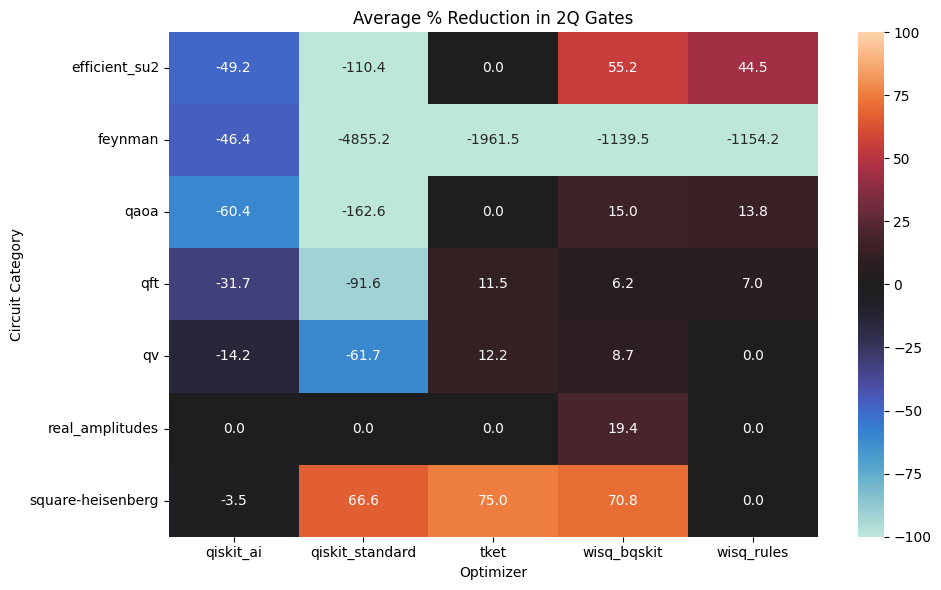

In [88]:
import numpy as np

df["percent_reduction"] = np.where(
    df["initial_two_qubit_gates"] > 0,
    (
        (df["initial_two_qubit_gates"] - df["final_two_qubit_gates"])
        / df["initial_two_qubit_gates"]
    ) * 100,
    np.nan
)

category_perf = (
    df.groupby(["original_category", "opt_1"])
      ["percent_reduction"]
      .mean()
      .reset_index()
)

pivot = category_perf.pivot(
    index="original_category",
    columns="opt_1",
    values="percent_reduction"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    center=0,
    vmin=-100,
    vmax=100,
    robust=True
)

plt.title("Average % Reduction in 2Q Gates")
plt.xlabel("Optimizer")
plt.ylabel("Circuit Category")
plt.tight_layout()
plt.show()

In [87]:
print(pivot.loc["feynman"])

opt_1
qiskit_ai         -inf
qiskit_standard   -inf
tket              -inf
wisq_bqskit       -inf
wisq_rules        -inf
Name: feynman, dtype: float64


In [79]:
feynman_df = df[df["original_category"] == "feynman"]

print(feynman_df[
    [
        "opt_1",
        "initial_two_qubit_gates",
        "final_two_qubit_gates",
        "percent_reduction"
    ]
])

               opt_1  initial_two_qubit_gates  final_two_qubit_gates  \
147             tket                        2                      6   
148             tket                        2                      6   
149             tket                        2                      6   
150             tket                        2                      6   
151             tket                        2                      6   
..               ...                      ...                    ...   
636             tket                       10                     58   
637        qiskit_ai                       10                      6   
638  qiskit_standard                       10                    105   
639  qiskit_standard                       10                    105   
640  qiskit_standard                       10                    105   

     percent_reduction  
147             -200.0  
148             -200.0  
149             -200.0  
150             -200.0  
151       

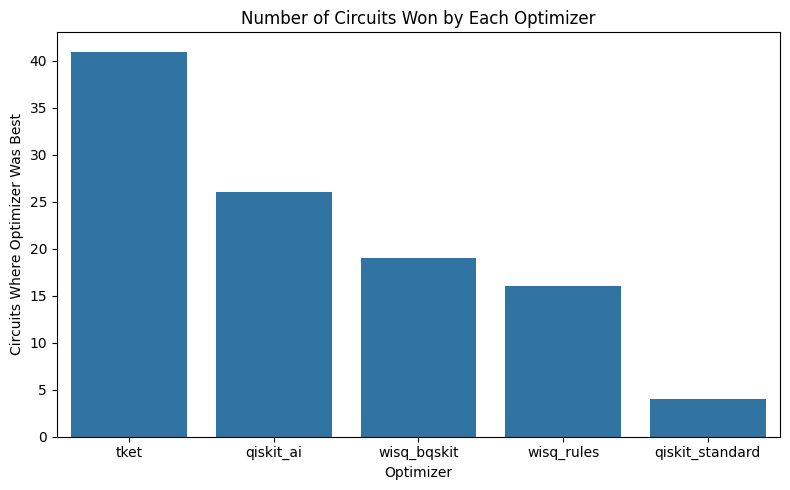

In [5]:
best_per_circuit = (
    df.sort_values(
        by=["final_two_qubit_gates", "final_depth"]
    )
    .groupby("original_circuit")
    .first()
    .reset_index()
)

optimizer_wins = (
    best_per_circuit["opt_1"]
    .value_counts()
    .reset_index()
)

optimizer_wins.columns = ["optimizer", "wins"]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=optimizer_wins,
    x="optimizer",
    y="wins"
)

plt.title("Number of Circuits Won by Each Optimizer")
plt.ylabel("Circuits Where Optimizer Was Best")
plt.xlabel("Optimizer")

plt.tight_layout()
plt.show()

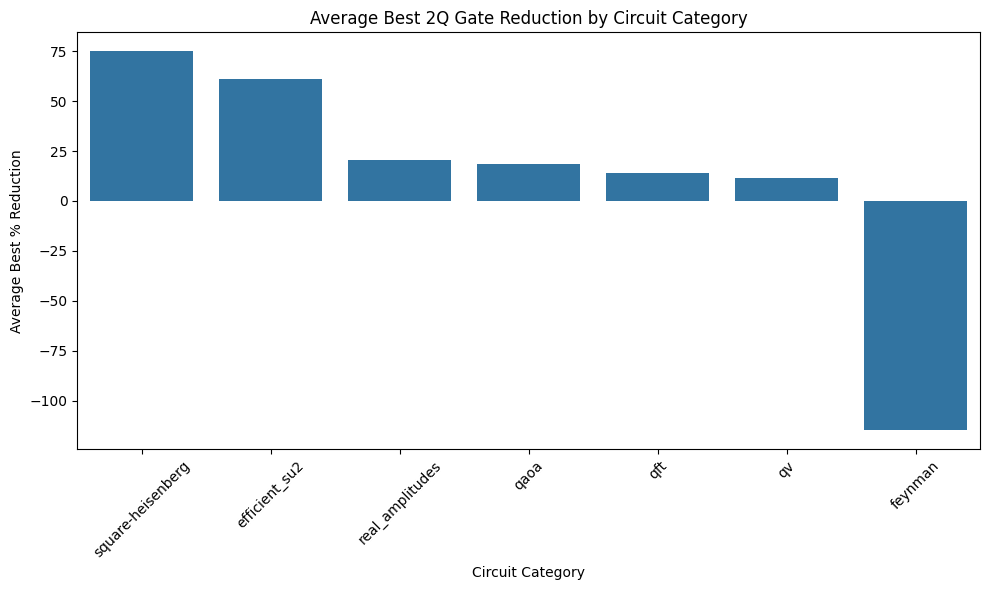

In [6]:
best_per_circuit = (
    df.sort_values(
        by=["final_two_qubit_gates", "final_depth"]
    )
    .groupby("original_circuit")
    .first()
    .reset_index()
)
import numpy as np

best_per_circuit["best_percent_reduction"] = np.where(
    best_per_circuit["initial_two_qubit_gates"] > 0,
    (
        (
            best_per_circuit["initial_two_qubit_gates"]
            - best_per_circuit["final_two_qubit_gates"]
        )
        / best_per_circuit["initial_two_qubit_gates"]
    ) * 100,
    np.nan
)
category_best = (
    best_per_circuit
    .groupby("original_category")["best_percent_reduction"]
    .mean()
    .reset_index()
    .sort_values(
        "best_percent_reduction",
        ascending=False
    )
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_best,
    x="original_category",
    y="best_percent_reduction"
)

plt.title(
    "Average Best 2Q Gate Reduction by Circuit Category"
)
plt.xlabel("Circuit Category")
plt.ylabel("Average Best % Reduction")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

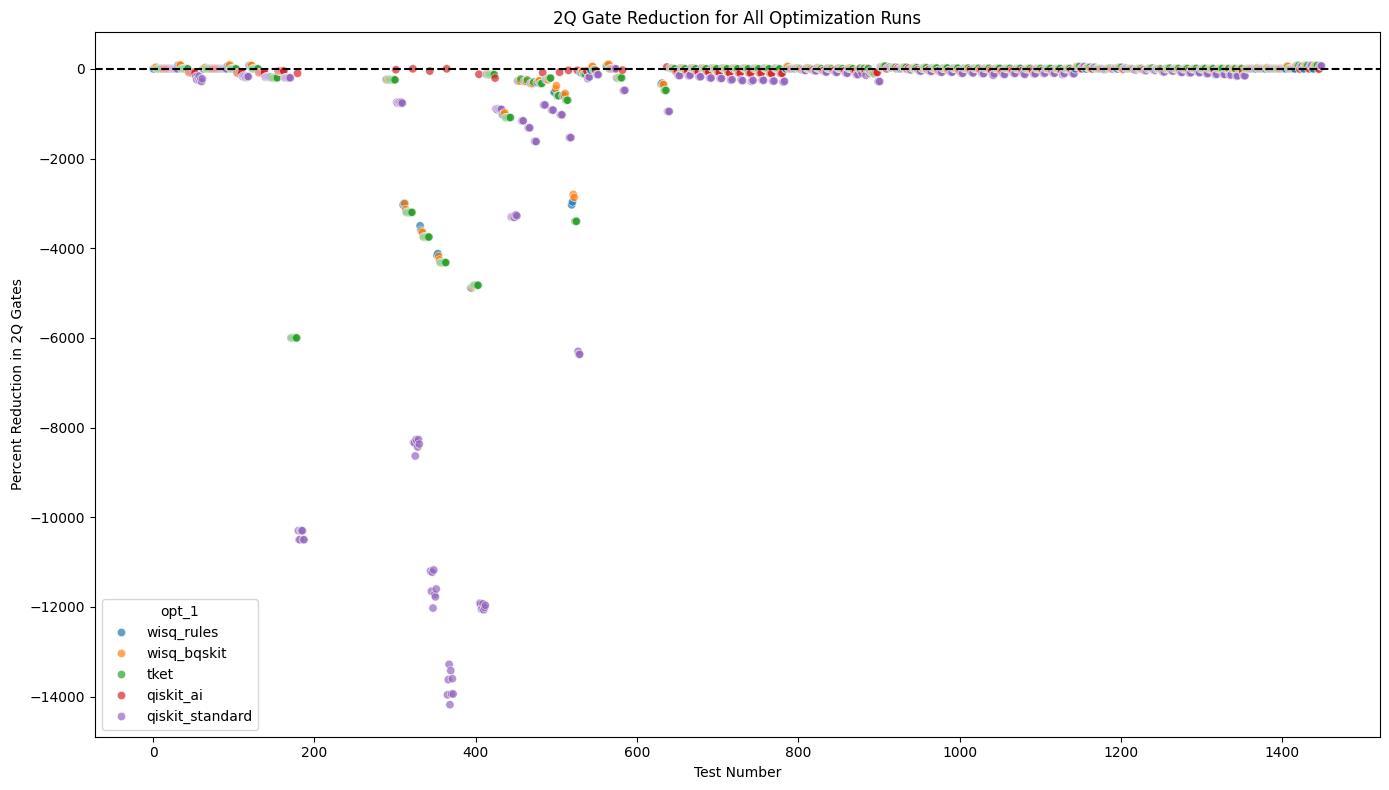

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = df.copy()

df["percent_reduction"] = np.where(
    df["initial_two_qubit_gates"] > 0,
    (
        (df["initial_two_qubit_gates"] - df["final_two_qubit_gates"])
        / df["initial_two_qubit_gates"]
    ) * 100,
    np.nan
)

df["test_number"] = range(len(df))

plt.figure(figsize=(14,8))

sns.scatterplot(
    data=df,
    x="test_number",
    y="percent_reduction",
    hue="opt_1",
    alpha=0.7
)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Test Number")
plt.ylabel("Percent Reduction in 2Q Gates")
plt.title("2Q Gate Reduction for All Optimization Runs")

plt.tight_layout()
plt.show()


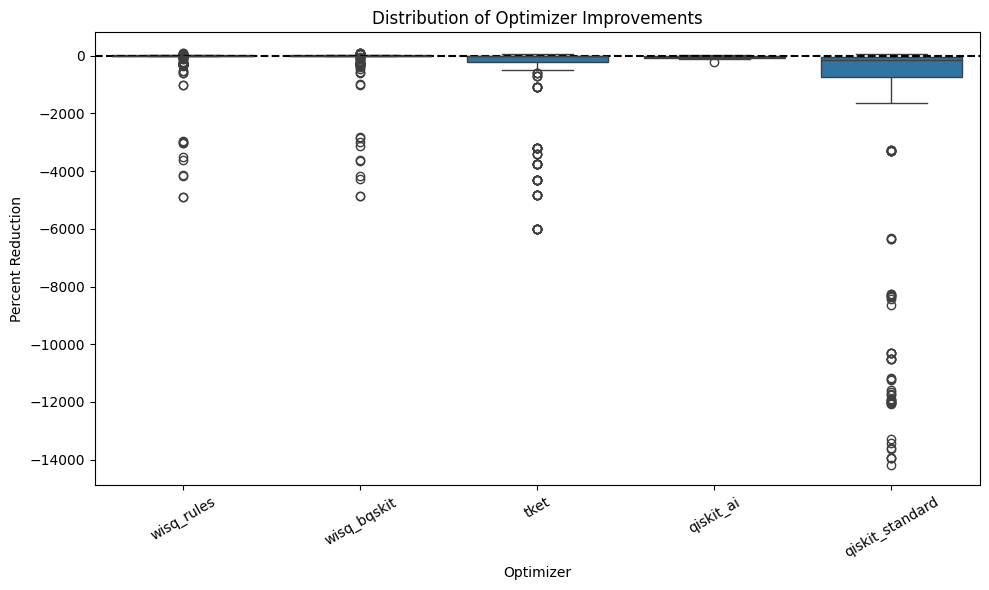

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="opt_1",
    y="percent_reduction"
)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Optimizer")
plt.ylabel("Percent Reduction")
plt.title("Distribution of Optimizer Improvements")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

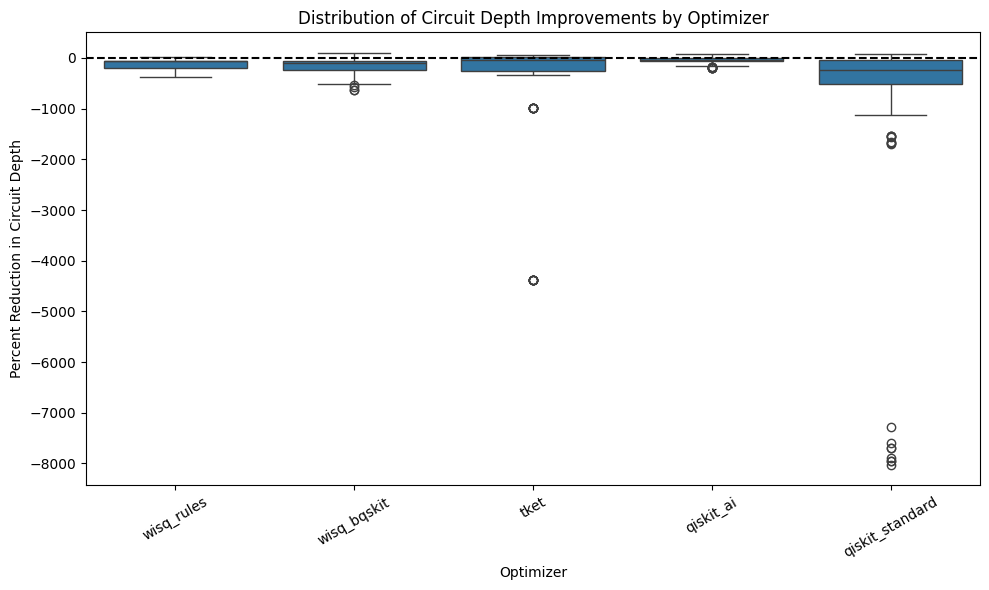

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate percent reduction in circuit depth
df["depth_percent_reduction"] = np.where(
    df["initial_depth"] > 0,
    (
        (df["initial_depth"] - df["final_depth"])
        / df["initial_depth"]
    ) * 100,
    np.nan
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="opt_1",
    y="depth_percent_reduction"
)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Optimizer")
plt.ylabel("Percent Reduction in Circuit Depth")
plt.title("Distribution of Circuit Depth Improvements by Optimizer")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()